# UBDS 2026: Basic Python
## Day 5: Machine learning and data science


### Topics covered / Сьогоднішні теми
1. Basic exploratory data analysis (EDA) / Першопочаткове дослідження даних
2. Correlation / Кореляція 
3. t-test / Тест Стьюдента
4. One-way ANOVA / Дисперсійний аналіз
5. Simple linear regression / Лінійна регресія
6. microProject/RF / Мікропроект/метод випадкового лісу 


We will use the palmers penguins dataset (`palmerpenguins_extended.csv`) which contains characteristics of penguins population over the years:
Будемо використовувати набір даних про пінгвінів Палмера(`palmerpenguins_extended.csv`), що містить характеристики популяції цих пінгвінів впродовж кількох років: 

- `species` / `вид`
- `island` / `острів`
- `bill_length_mm` / `довжина клюву`
- `bill_depth_mm` / `глибина клюву`
- `flipper_length_mm` `довжина плавців`
- `body_mass_g` / `маса тіла`
- `sex` / `стать`
- `diet` / `дєта`
- `life_stage` / `стадія життя`
- `health_metrics` / `здоров'я`
- `year` / `рік`


# Import the tools we need

- `pandas` helps us work with tables of data / для роботи з таблицями
- `numpy` is needed to work with numerical data / для роботи з числовими данними
- `matplotlib` helps us make plots / для графіків
- `scipy.stats` gives us statistical tests / для статистичних тестів
- `statsmodels` gives us additional statistical tests / для додаткових тестів
- `LinearRegression` from `sklearn` helps us build a simple regression model / для лінійної регресії
- `PolynomialFeatures` from sklearn gives us  way to build polynomial models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

ModuleNotFoundError: No module named 'scipy'

# Load the dataset

Note - be sure that file actually exist at the given location / Переконайтеся що вказаний шлях є вірним

Common name for a dataframe - df. / Типове ім'я для датафрейму ДФ.

In [2]:
df = pd.read_csv("palmerpenguins_extended.csv")
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,diet,life_stage,health_metrics,year
0,Adelie,Biscoe,53.4,NaN,219.0,5687.0,female,fish,adult,overweight,2021
1,Adelie,Biscoe,49.3,18.1,NaN,6811.0,female,fish,adult,overweight,2021
2,Adelie,Biscoe,55.7,16.6,226.0,5388.0,female,fish,adult,overweight,2021
3,Adelie,Biscoe,38.0,15.6,221.0,6262.0,female,fish,adult,overweight,2021
4,Adelie,Biscoe,60.7,17.9,177.0,4811.0,female,fish,juvenile,overweight,2021
...,...,...,...,...,...,...,...,...,...,...,...
3425,Gentoo,Biscoe,44.0,20.4,252.0,6447.0,male,squid,adult,healthy,2025
3426,Gentoo,Biscoe,54.5,25.2,245.0,6872.0,male,squid,adult,healthy,2025
3427,Gentoo,Biscoe,51.4,20.4,258.0,7409.0,male,squid,adult,overweight,2025
3428,Gentoo,Biscoe,55.9,20.5,247.0,6491.0,male,squid,adult,healthy,2025


![Island](https://education.rstudio.com/blog/2020/07/palmerpenguins-cran/antarctica-map.png)


![Penguin](https://allisonhorst.github.io/palmerpenguins/reference/figures/culmen_depth.png)


# First look at the data

To repeat previous lesson - please print: / Для закріплення вчорашнього дня - будь ласка визначте 
- the first few rows / Перші кілька строчок  
- the last few rows / Останні кілька строчок 
- the shape of the table / Форма таблиці 
- the column names / Імена колонок
- the data types in each column / Типи даних в колонках
- rows number 5 and 10 / строчки номер 5 і 10
- flipper length column / колонку що містить довжину плавців

In [3]:
# Your code goes here


In [4]:
# Your code goes here


In [5]:
# Your code goes here


In [6]:
# Your code goes here


In [7]:
# Your code goes here


In [8]:
# Your code goes here


In [9]:
# Your code goes here


# Missing values

A missing value is called NA(NA-Not assesed) and it means some information is absent / Відсутнє значення називають NA, і це значить що частина інформації відсутня.

We can count missing values in each column like this / Ми можемо порахувати відсутні значення наступним чином.

In [10]:
df.isna().sum()

species                0
island                 0
bill_length_mm        10
bill_depth_mm        137
flipper_length_mm    240
body_mass_g          103
sex                   41
diet                   0
life_stage             0
health_metrics         0
year                   0
dtype: int64

We have two strategies how to deal with NA. First one is simply removing them. / У нас є дві стратегії як розбиратися з NA. Перший варіант просто їх прибрати.

In [11]:
df_drop = df.dropna()
df_drop.shape

(2930, 11)

In [12]:
df_drop.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
diet                 0
life_stage           0
health_metrics       0
year                 0
dtype: int64

Second option is to impute them using mean or median / Наступний варіант це заповнити їх використовуючи середнє чи медіану

In [13]:
df_fill = df.copy()

df_fill["body_mass_g"] = df_fill["body_mass_g"].fillna(
    df_fill["body_mass_g"].mean()
)

df_fill["flipper_length_mm"] = df_fill["flipper_length_mm"].fillna(
    df_fill["flipper_length_mm"].median()
)

#inpute lenght of bil with mean and depth of bill with median / зааповніть довжину клюва середнім значенням і глибину клюва медіаною

#

df_fill.isna().sum()

species                0
island                 0
bill_length_mm        10
bill_depth_mm        137
flipper_length_mm      0
body_mass_g            0
sex                   41
diet                   0
life_stage             0
health_metrics         0
year                   0
dtype: int64

In [14]:
df=df.dropna()

# Looking at categories

Some columns contain categories, not numbers. / В деяких колонках маємо категорії а не числа

Examples:
- species
- island
- sex
- diet
- life_stage
- health_metrics


In [15]:
df["species"].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [16]:
df["island"].unique()

array(['Biscoe', 'Dream', 'Torgensen'], dtype=object)

In [17]:
df["sex"].unique()

array(['female', 'male'], dtype=object)

In [18]:
df["life_stage"].unique()

array(['adult', 'juvenile', 'chick'], dtype=object)

In [19]:
df["health_metrics"].unique()

array(['overweight', 'healthy', 'underweight'], dtype=object)

## Exercise 2

Use the `.unique()` results above to answer:

1. How many species are in the dataset?
2. How many islands are in the dataset?


# Basic descriptive statistics

Descriptive statistics help us summarize numeric variables.  / Описова статистика допомогає нам дослідити числові значення.

Typical examples:
- mean
- standard deviation
- minimum
- maximum
- quartiles

We can get using one function / Для цього у нас є одна проста функція

In [20]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,38.460137,18.422457,206.862799,4825.317747,2023.357338
std,13.181151,2.771981,28.868658,1312.744023,1.315255
min,13.600000,9.700000,140.000000,2508.000000,2021.000000
25%,28.800000,16.600000,185.000000,3845.000000,2022.000000
50%,34.450000,18.400000,203.000000,4618.500000,2024.000000
75%,46.500000,20.300000,225.000000,5594.000000,2024.000000
max,88.200000,27.900000,308.000000,10549.000000,2025.000000


## Focus on one variable

We can also inspect one column at a time. / Також ми можемо отримати таку статистику для однієї колонки

In [21]:
df["body_mass_g"].describe()

count     2930.000000
mean      4825.317747
std       1312.744023
min       2508.000000
25%       3845.000000
50%       4618.500000
75%       5594.000000
max      10549.000000
Name: body_mass_g, dtype: float64

# Simple filtering

Filtering means selecting only the rows we want / Фільтрування обирає тільки ті строчки що відповідають певній умові

For repetition filter:
- only Adelie penguins
- only adult penguins
- only male penguins
- only penguins from Biscoe island and male:

In [22]:
# Your code goes here


In [23]:
# Your code goes here


In [24]:
# Your code goes here


In [25]:
# Your code goes here


# Counting categories

To work with categories we can count them. / Аби працювати з категоріями ми можемо їх порахувати

For that we use `value_counts()`.

In [26]:
df["species"].value_counts()

species
Adelie       1334
Gentoo       1063
Chinstrap     533
Name: count, dtype: int64

## Relative frequencies

Sometimes we want percentages instead of raw counts. / Інколи ми хочемо оперувати не сирими значеннями, а частотами

We can do that with `normalize=True`.

In [28]:
df["species"].value_counts(normalize=True)

species
Adelie       0.455290
Gentoo       0.362799
Chinstrap    0.181911
Name: proportion, dtype: float64

# Group summaries

Group summaries are used to count group-wise statistics. / Групування використовується аби рахувати погрупову статистику.

As a reminder lets calculate / Як нагадування давайте порахуємо
- What is the average body mass for each species? / Середю вагу для різних видів
- What is the avrage flipper length for each island? / Середню довжину плавців на різних островах
- What is the median bill length for males and females? / Медіанну довжини клюва серед різних статей
- What is the frequencies of different species occurence on each island/  Якою є частота різних видів на кожному острові

The general pattern is:
`df.groupby("group_column")["numeric_column"].mean()`

In [29]:
df.groupby("species")["body_mass_g"].mean()

species
Adelie       4409.663418
Chinstrap    4613.236398
Gentoo       5453.278457
Name: body_mass_g, dtype: float64

In [30]:
# Your code goes here


In [31]:
# Your code goes here


In [32]:
# Your code goes here


## Group by more than one column

We can also group by two variables. Також можна групувати по двом або більше колонкам

In [33]:
df.groupby(["species", "sex"])["body_mass_g"].mean()

species    sex   
Adelie     female    4074.150289
           male      4771.306854
Chinstrap  female    4235.328720
           male      5060.840164
Gentoo     female    4913.241107
           male      5943.868941
Name: body_mass_g, dtype: float64

## Histogram

A histogram shows the distribution of one numeric variable.

Here we plot `body_mass_g`.

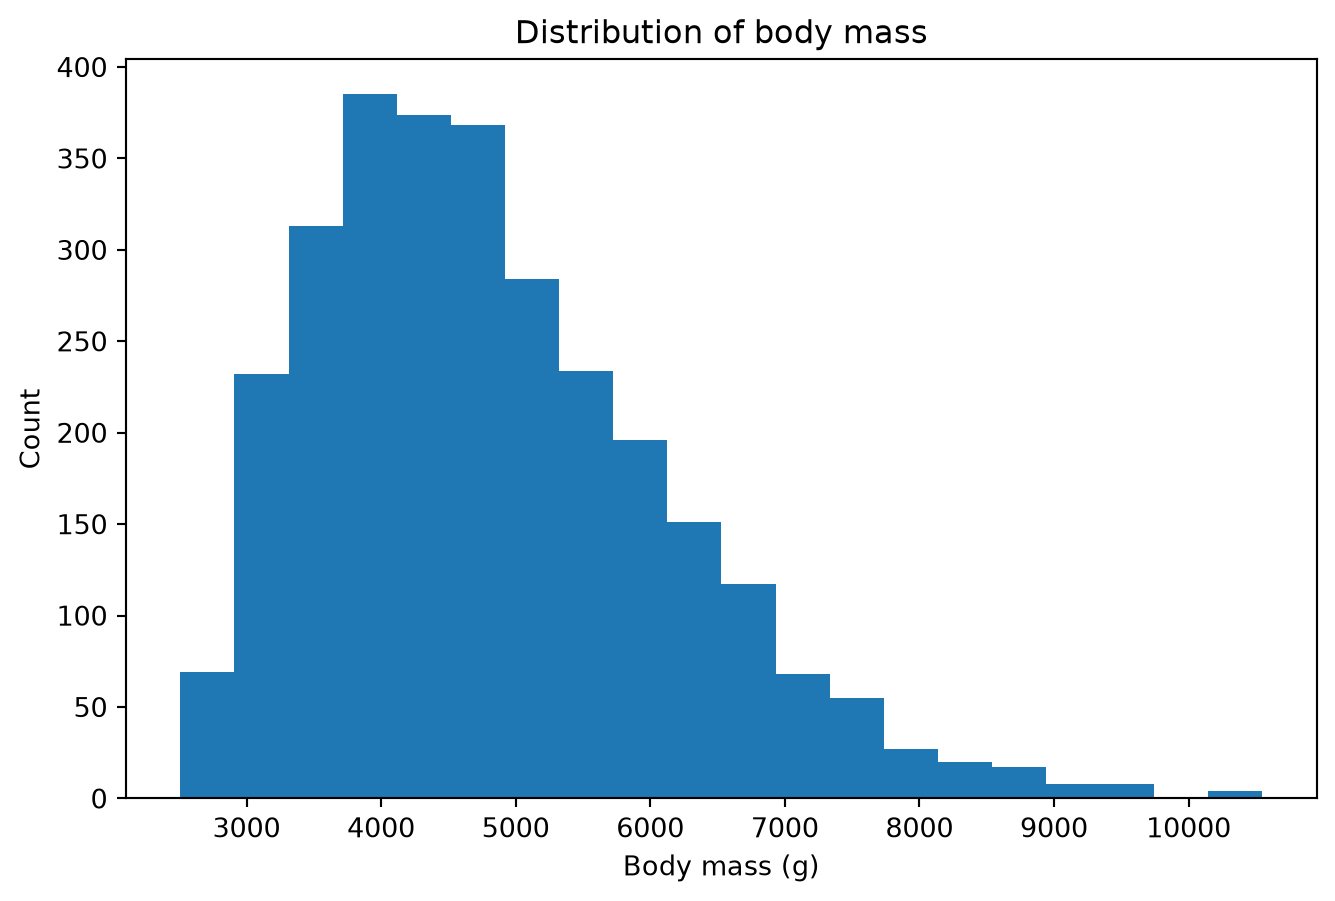

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(df["body_mass_g"], bins=20)
plt.title("Distribution of body mass")
plt.xlabel("Body mass (g)")
plt.ylabel("Count")
plt.show()

## Bar chart of category counts

Bar charts are useful for categorical variables.

Here we count penguins by species.

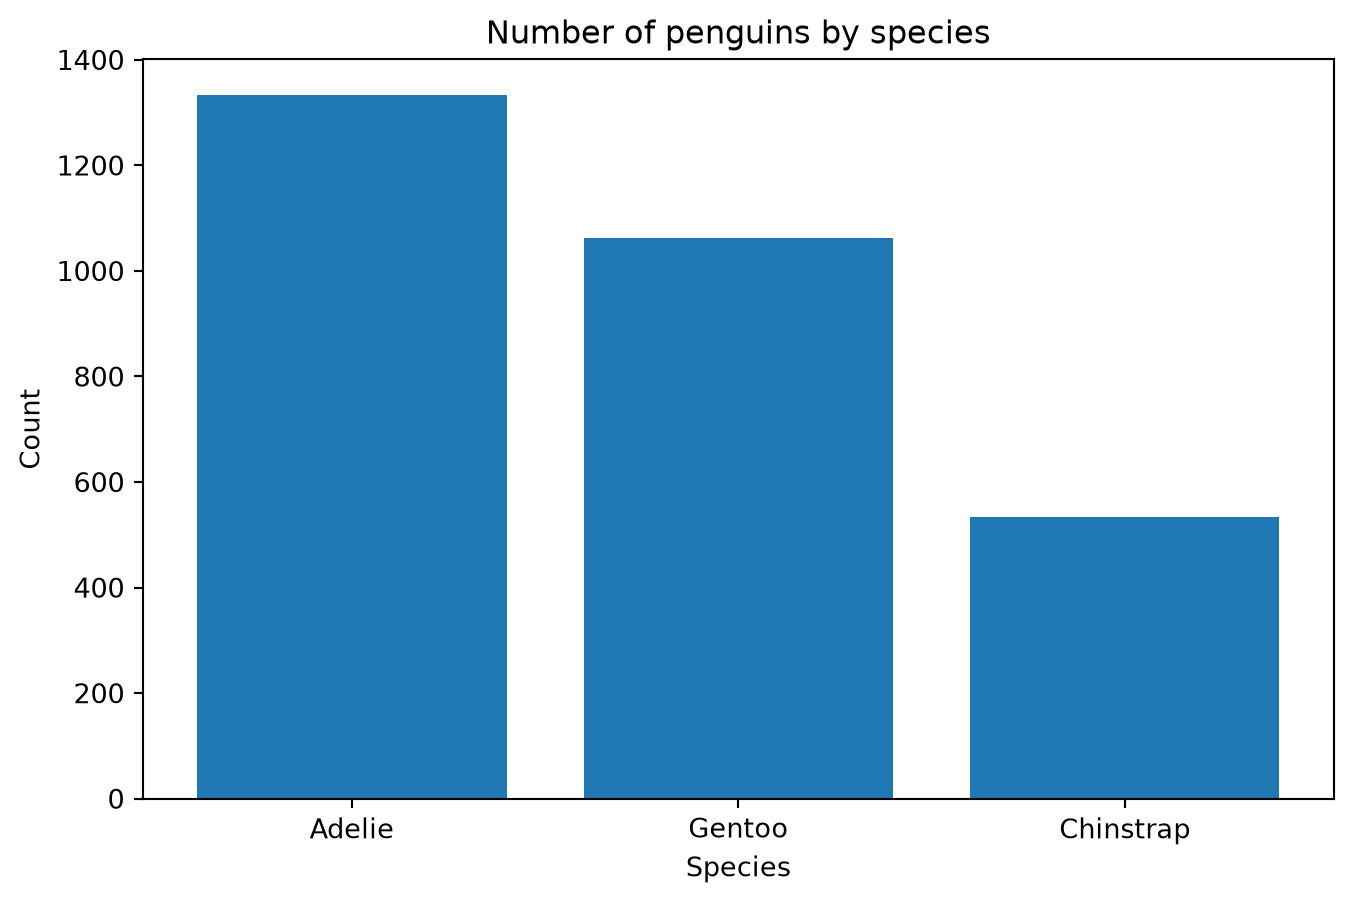

In [35]:
species_counts = df["species"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(species_counts.index, species_counts.values)
plt.title("Number of penguins by species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

## Scatter plot

A scatter plot shows the relationship between two numeric variables.

Here we compare:
- `flipper_length_mm`
- `body_mass_g`

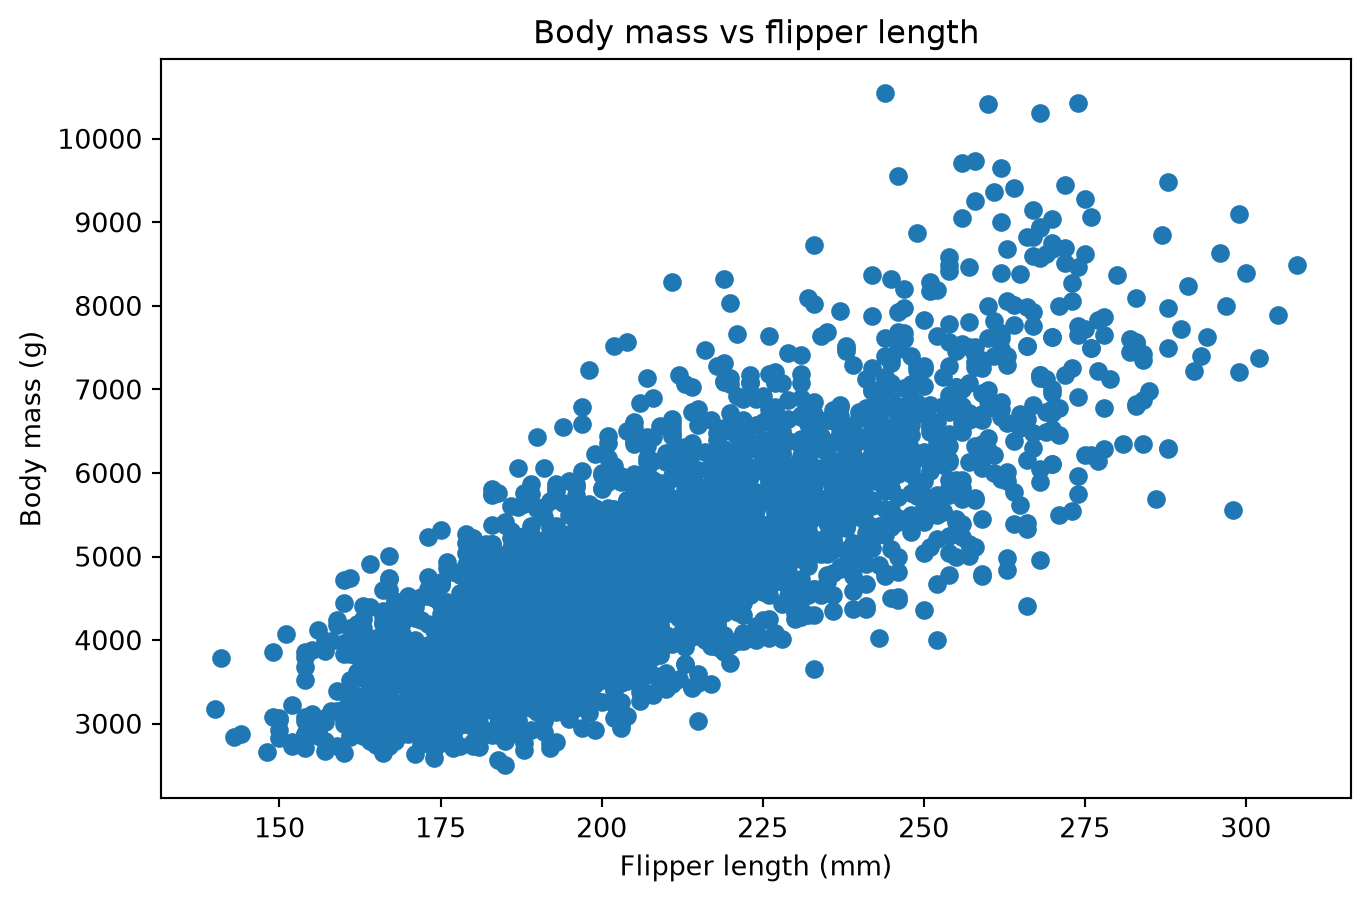

In [36]:
plt.figure(figsize=(8, 5))
plt.scatter(df["flipper_length_mm"], df["body_mass_g"])
plt.title("Body mass vs flipper length")
plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.show()

## Boxplot

A boxplot helps compare distributions across groups.

Here we compare body mass for the three species.

In [37]:
adelie_mass = df[df["species"] == "Adelie"]["body_mass_g"]
chinstrap_mass = df[df["species"] == "Chinstrap"]["body_mass_g"]
gentoo_mass = df[df["species"] == "Gentoo"]["body_mass_g"]

plt.figure(figsize=(8, 5))
data_box=[adelie_mass, chinstrap_mass, gentoo_mass]
plt.boxplot(data_box, labels=["Adelie", "Chinstrap", "Gentoo"])
plt.title("Pengui")
plt.ylabel("Body mass")
plt.show()

TypeError: boxplot() got an unexpected keyword argument 'labels'

<Figure size 768x480 with 0 Axes>

Make the following plots:

1. histogram of `bill_length_mm`
2. bar chart of counts for `life_stage`
3. scatter plot of `bill_length_mm` vs `bill_depth_mm`
4. boxplot of `flipper_length_mm` by sex

In [38]:
# Your code goes here


In [39]:
# Your code goes here


In [40]:
# Your code goes here


In [41]:
# Your code goes here


# Correlation

Corelation measure the strength and direction of a linear(and non-linear) relationship between two numeric variables. / Кореляція вимірює сили та напрямок лінійного та нелінійного зв'язку між двома змінними

The correlation coefficient is usually written as **r**.

Its values are between **-1** and **1**.

- close to `1` strong positive relationship
- close to `-1` strong negative relationship
- close to `0`  weak or no linear relationship


In [42]:
df["body_mass_g"].corr(df["flipper_length_mm"])

0.7941249625791258

How to work - with non-linear relationship - **Spearman** correlation(but first normality test) / Як працювати з нелінійною кореляцією - використовувати кореляцію **Спірмана**, перед тим перевіривши номральність

In [43]:
stat, p_value = shapiro(df["body_mass_g"])

print("Shapiro test statistic:", stat)
print("p-value:", p_value)

NameError: name 'shapiro' is not defined

In [44]:
stat, p_value = shapiro(df["flipper_length_mm"])

print("Shapiro test statistic:", stat)
print("p-value:", p_value)

NameError: name 'shapiro' is not defined

If our **pvalue <0.05** we can assume non-normality, in this case lets use Spearman correlation

In [45]:
num_df = df[["body_mass_g","bill_depth_mm"]].dropna()

corr_spearman = num_df.corr(method="spearman")

print("\nSpearman correlation:\n", corr_spearman)



Spearman correlation:
                body_mass_g  bill_depth_mm
body_mass_g       1.000000       0.567772
bill_depth_mm     0.567772       1.000000


Calculate Spearman and Pearson correlation for body mass and flippers lenght / Порахуйте кореляцію Спірмана та Пірсона для маси тіла та довжини плавців.

In [46]:
# Your code goes here


## Correlation matrix

A correlation matrix shows pairwise correlations for several numeric variables at once. We can make a table out of it.

In [47]:
numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "year"]
df[numeric_cols].corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
bill_length_mm,1.000000,0.309348,0.669156,0.661494,0.007161
bill_depth_mm,0.309348,1.000000,0.484506,0.559335,-0.019208
flipper_length_mm,0.669156,0.484506,1.000000,0.794125,0.002910
body_mass_g,0.661494,0.559335,0.794125,1.000000,-0.001642
year,0.007161,-0.019208,0.002910,-0.001642,1.000000


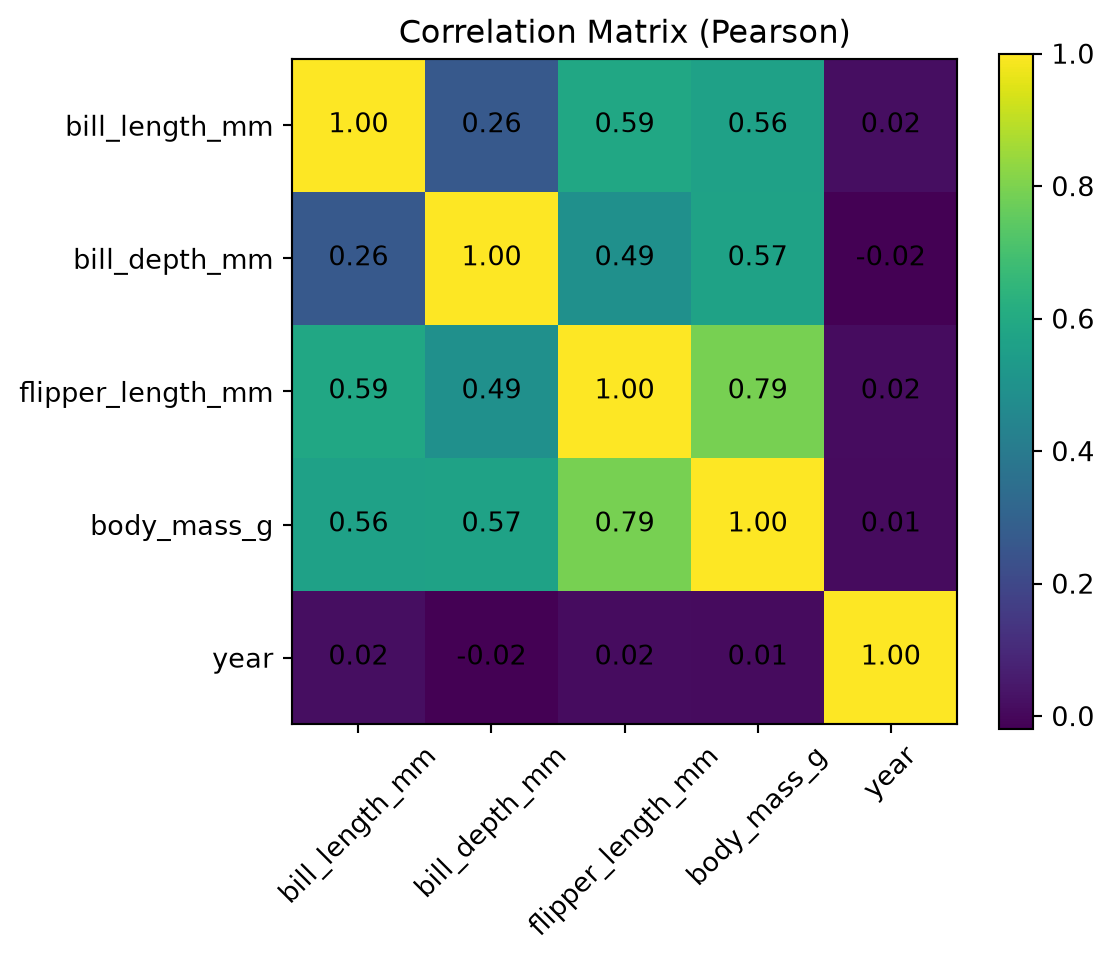

In [48]:
corr = df[numeric_cols].corr(method="spearman")

plt.figure(figsize=(6, 5))
plt.imshow(corr, interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha='center', va='center', color='black')

plt.title("Correlation Matrix (Pearson)")
plt.tight_layout()
plt.show()

Not all python libraries are made equal - **seaborn** provide much faster and easier way to do same plot

In [49]:
import seaborn as sns
num_df = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
corr = num_df.corr(method="spearman")


sns.heatmap(
    corr,
    annot=corr.values,
    cmap="coolwarm",
    center=0,
    square=True)

plt.title("Correlation Matrix (Seaborn)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'seaborn'

In [50]:
corr.values

array([[ 1.        ,  0.26348741,  0.58696801,  0.56172155,  0.01575469],
       [ 0.26348741,  1.        ,  0.49165868,  0.56777196, -0.02011918],
       [ 0.58696801,  0.49165868,  1.        ,  0.79200685,  0.01506566],
       [ 0.56172155,  0.56777196,  0.79200685,  1.        ,  0.00958891],
       [ 0.01575469, -0.02011918,  0.01506566,  0.00958891,  1.        ]])

# t-test

A t-test compares the means of two groups. / Т-тест потрібен для порівняння двох груп.

We need:
- one numeric variable
- one grouping variable with two groups

Do adult male and adult female penguins differ in average body mass? / Чи мають дорослі самці і самки відмінності у масі тіла?

In [51]:
adult = df[df["life_stage"] == "adult"]

male_mass = adult[adult["sex"] == "male"]["body_mass_g"]
female_mass = adult[adult["sex"] == "female"]["body_mass_g"]

male_mass.describe(), female_mass.describe()

(count      431.000000
 mean      6564.786543
 std       1300.619062
 min       3655.000000
 25%       5537.000000
 50%       6427.000000
 75%       7453.500000
 max      10549.000000
 Name: body_mass_g, dtype: float64,
 count     440.000000
 mean     5415.415909
 std       955.510252
 min      3218.000000
 25%      4659.250000
 50%      5348.500000
 75%      6076.000000
 max      8055.000000
 Name: body_mass_g, dtype: float64)

## Hypotheses of the t-test

- **Null hypothesis (H0):** the mean body mass is the same in adult males and adult females
- **Alternative hypothesis (H1):** the mean body mass is different

We will use Welch's t-test by setting `equal_var=False`. 

In [52]:
ttest_result = stats.ttest_ind(male_mass, female_mass, equal_var=False)
ttest_result

NameError: name 'stats' is not defined

## Interpreting the result

The output gives:
- a t statistic
- a p-value

If the p-value is small, we reject the null hypothesis.

A common threshold is **0.05**.

- if `p < 0.05`: evidence of a difference
- if `p >= 0.05`: not enough evidence of a difference

Run a t-test to compare `bill_length_mm` between male and female adult penguins.

Steps:
1. filter only adults
2. split bill length into male and female groups
3. run stats.ttest_ind
4. compare the means

In [53]:
# Your code goes here


In [54]:
male_bill.mean(), female_bill.mean()

NameError: name 'male_bill' is not defined

# One-way ANOVA

ANOVA stands for **Analysis of Variance**. It is needed to compare more than 2 groups.

**Do adult penguin species differ in average flipper length?**

In [55]:
adult = df[df["life_stage"] == "adult"]

adelie_flipper = adult[adult["species"] == "Adelie"]["flipper_length_mm"]
chinstrap_flipper = adult[adult["species"] == "Chinstrap"]["flipper_length_mm"]
gentoo_flipper = adult[adult["species"] == "Gentoo"]["flipper_length_mm"]

adult.groupby("species")["flipper_length_mm"].mean()

species
Adelie       225.377660
Chinstrap    223.855172
Gentoo       242.611429
Name: flipper_length_mm, dtype: float64

In [56]:
anova_result = stats.f_oneway(adelie_flipper, chinstrap_flipper, gentoo_flipper)
anova_result

NameError: name 'stats' is not defined

## Hypotheses for ANOVA

- **Null hypothesis (H0):** all group means are equal
- **Alternative hypothesis (H1):** at least one group mean is different

If the p-value is below 0.05, we conclude that not all means are equal.

## Important ANOVA note

ANOVA tells us that a difference exists somewhere among the groups.  / Анова каже нам чи існує різниця між групами
It does **not** automatically tell us exactly which pairs differ. / Вона не каже, між якими саме групами
To get whihc groups differs we need to run post-hoc test  - TukeyHSD. / Щоб це визначити маємо використати додатковий тест-Тьюкі

In [57]:

anova_data = df[["species", "flipper_length_mm"]].dropna()

tukey = pairwise_tukeyhsd(
    endog=anova_data["flipper_length_mm"],  
    groups=anova_data["species"],  
    alpha=0.05)

print(tukey)

NameError: name 'pairwise_tukeyhsd' is not defined

Use one-way ANOVA to test whether mean ``body mass`` differs among the three ``species``.

Steps:
1. filter to adults / Відфільтруйте дорослих 
2. create three groups / Створіть три групи 
3. run stats.f_oneway / Проведіть анову
4. run post hoc test / Проведіть тест тьюкі

In [58]:
# Your code goes here


# Simple linear regression

Linear regression models the relationship between: / Лінійна регресія визначає зв'язок між одним предиктором(Х-змінна) та одним цільовим значенням (У-змінна)

- one predictor variable `X`
- one or more outcome variable `y`

We will predict:

- `body_mass_g` from `flipper_length_mm`

This is called **simple linear regression** because there is only one predictor.

## The general idea

The model tries to find a line:

`predicted body mass = intercept + slope × flipper length`

- the **intercept** is where the line starts
- the **slope** tells us how much the predicted outcome changes when the predictor increases by 1 unit

In [60]:
X = df[["flipper_length_mm"]]
y = df["body_mass_g"]

model = LinearRegression()
model.fit(X, y)

NameError: name 'LinearRegression' is not defined

## Model coefficients

In [61]:
model.coef_, model.intercept_

NameError: name 'model' is not defined

### Interpretation

If the slope is positive, then larger flipper length is associated with larger predicted body mass.

## R-squared

`R^2` tells us how much variation in the outcome is explained by the predictor.

- closer to 1 means stronger explanatory power
- closer to 0 means weaker explanatory power

In [62]:
model.score(X, y)

NameError: name 'model' is not defined

## Make predictions

We can ask the model to predict body mass for given flipper lengths.

In [63]:
new_penguins = pd.DataFrame({"flipper_length_mm": [180, 190, 200, 210, 220]})
model.predict(new_penguins)

NameError: name 'model' is not defined

## Plot the regression line

We will:
1. draw the scatter plot
2. create predicted values
3. draw a line through those predictions

In [64]:
predicted_y = model.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X["flipper_length_mm"], y)
plt.plot(X["flipper_length_mm"], predicted_y, color="red")
plt.title("Linear regression: body mass vs flipper length")
plt.xlabel("Flipper length")
plt.ylabel("Body mass")
plt.show()

NameError: name 'model' is not defined

Fit a linear regression model to predict `bill_depth_mm` from `body_mass_g`.

Tasks:
1. create `X` from `bill_length_mm`
2. create `y` from `body_mass_g`
3. fit a `LinearRegression()` model
4. print the slope, intercept, and `R^2`

In [65]:
# Your code goes here


Linear regression can include more than 1 variable,  it is called ``Multiple Linear Regression``

General formula would look like  ``predicted body mass = intercept + slope1 × flipper length + slope2 × bill length + slope3 × bill depth``

In [66]:
X = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]]
y = df["body_mass_g"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)


NameError: name 'LinearRegression' is not defined

In [67]:
model.score(X, y)

NameError: name 'model' is not defined

### Feature scaling (normalization)

In regression, different features may have very different scales:

- body_mass_g in thousands units - g
- bill_length_mm in tens units - mm

This can affect:
- interpretation of coefficients
- numerical stability of models

Two common approaches:

1. **Standardization (Z-score)**  
   transforms data to mean = 0, std = 1

2. **Min-Max scaling**  
   scales data between 0 and 1

In [68]:
df[["bill_length_mm","flipper_length_mm","body_mass_g"]].dropna().describe()



,bill_length_mm,flipper_length_mm,body_mass_g
count,2930.000000,2930.000000,2930.000000
mean,38.460137,206.862799,4825.317747
std,13.181151,28.868658,1312.744023
min,13.600000,140.000000,2508.000000
25%,28.800000,185.000000,3845.000000
50%,34.450000,203.000000,4618.500000
75%,46.500000,225.000000,5594.000000
max,88.200000,308.000000,10549.000000


In [69]:
data_sc= df[[
    "bill_length_mm", 
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"]].dropna()

X = data_sc.drop(columns=["body_mass_g"])
y = data_sc["body_mass_g"]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

NameError: name 'StandardScaler' is not defined

In [70]:
model_scaled = LinearRegression()
model_scaled.fit(X_scaled, y)

print("R²:", model_scaled.score(X_scaled, y))

NameError: name 'LinearRegression' is not defined

In [71]:
print("Original coefficients:")
for name, coef in zip(X.columns, model.coef_):
    print(f"{name}: {coef:.2f}")

print("Scaled coefficients:")
for name, coef in zip(X.columns, model_scaled.coef_):
    print(f"{name}: {coef:.2f}")

Original coefficients:


NameError: name 'model' is not defined

Regression can include not only numerical, but also a ``categorical`` features
To add them to our model they must be converted into numerical form.

One common method is **one-hot encoding**:
- each category becomes a separate column
- values are 0 or 1


In [72]:

data = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "species", "body_mass_g"]]

data_encoded = pd.get_dummies(data,  columns=["species"], drop_first=True)
data_encoded

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Chinstrap,species_Gentoo
2,55.7,16.6,226.0,5388.0,False,False
3,38.0,15.6,221.0,6262.0,False,False
4,60.7,17.9,177.0,4811.0,False,False
5,35.7,16.8,194.0,5266.0,False,False
6,61.0,20.8,211.0,5961.0,False,False
...,...,...,...,...,...,...
3425,44.0,20.4,252.0,6447.0,False,True
3426,54.5,25.2,245.0,6872.0,False,True
3427,51.4,20.4,258.0,7409.0,False,True
3428,55.9,20.5,247.0,6491.0,False,True


In [73]:
X = data_encoded.drop(columns=["body_mass_g"])
y = data_encoded["body_mass_g"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
for name, coef in zip(X.columns, model.coef_):
    print(f"{name}: {coef:.2f}")

NameError: name 'LinearRegression' is not defined

In [74]:
model.score(X, y)

NameError: name 'model' is not defined

## Why there cannot be one general solution

Sometimes one regression line is not enough for the whole dataset.

If the dataset contains groups, such as islands, each group may have a different relationship between variables.

Here we will build a separate regression for each island and plot them together.

In [75]:
reg_data = df[["island", "flipper_length_mm", "body_mass_g"]].dropna()


plt.figure(figsize=(8, 6))

for island in reg_data["island"].unique():
    island_data = reg_data[reg_data["island"] == island]

    X = island_data[["flipper_length_mm"]]
    y = island_data["body_mass_g"]

    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)
    sorted_idx = island_data["flipper_length_mm"].argsort()
    x_sorted = island_data["flipper_length_mm"].iloc[sorted_idx]
    y_sorted = y_pred[sorted_idx]
    
    plt.scatter(
        island_data["flipper_length_mm"],
        island_data["body_mass_g"],
        alpha=0.6,
        label=f"{island} data")

    plt.plot(
        x_sorted,
        y_sorted,
        linewidth=2,
        label=f"{island} regression")

plt.xlabel("Flipper length")
plt.ylabel("Body mass")
plt.title("Separate regression lines for each island")
plt.legend()
plt.show()

NameError: name 'LinearRegression' is not defined

<Figure size 768x576 with 0 Axes>

Now lets create a tidy function from the messy code above

In [76]:
def plot_grouped_regression(data, group_col, x_col, y_col):
    plt.figure(figsize=(8, 6))

    for group in data[group_col].unique():
        group_data = data[data[group_col] == group]

        X = group_data[[x_col]]
        y = group_data[y_col]

        model = LinearRegression()
        model.fit(X, y)

        y_pred = model.predict(X)

        sorted_idx = group_data[x_col].argsort()
        x_sorted = group_data[x_col].iloc[sorted_idx]
        y_sorted = y_pred[sorted_idx]

        plt.scatter(group_data[x_col], group_data[y_col], alpha=0.6, label=f"{group} data")
        plt.plot(x_sorted, y_sorted, linewidth=2, label=f"{group} regression")

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"Separate regression lines for each {group_col}")
    plt.legend()
    plt.show()

In [77]:
island_data = df[["island", "flipper_length_mm", "body_mass_g"]]
plot_grouped_regression(island_data, "island", "flipper_length_mm", "body_mass_g")

NameError: name 'LinearRegression' is not defined

<Figure size 768x576 with 0 Axes>

Now please build a separate regression line for each species/ Тепер побудуйте окрему модель лінійної регресії для кожного виду

In [78]:
# Your code goes here


## Train/Test Split

When building a model, we should not evaluate it on the same data we used for training. / Коли ми тренуємо нашу модель ми маємо визначати її точність не на тих самих даних на яких тренували(не так як ми робили вище;)

Instead, we split the dataset into:

- **training set** used to train the model
- **test set** used to evaluate the model

This helps us understand how well the model performs on new, unseen data.

In [79]:
X = data_encoded.drop(columns=["body_mass_g"])
y = data_encoded["body_mass_g"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  random_state=2026)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

NameError: name 'train_test_split' is not defined

If Train R ≈ Test R model generalizes well

If Train R > Test R model may be overfitting

In [80]:
model = LinearRegression()
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R:", train_score)
print("Test R:", test_score)

NameError: name 'LinearRegression' is not defined

## Cross-validation

Train/test split uses only one split of the data.

Cross-validation improves this by:
splitting data multiple times
training and testing multiple models
averaging the results

This gives a more reliable estimate of model performance.

In [81]:
model = LinearRegression()
scores = cross_val_score(model, X,y, cv=5,  scoring="r2")

print("Cross-validation scores:", #Wat should be there ?/Якого аргументи не вистачає?)
#Also provide average score / Також порахуйте середню точність моделі
print("Mean R²:", #

SyntaxError: incomplete input (2654872748.py, line 6)

1. Change test_size to 0.3. What happens? /  Змініть розміри тест сету, як змінюютсья резульати?
2. Try cv=3 and cv=10. How do results change? / Спробуйте використати іншу кількість валідацій. Як змінюються результати?


## Polynomial regression on synthetic data

In real datasets relationships are not always perfectly linear.

To understand polynomial regression clearly, we will first create some synthetic non-linear data

In [84]:
np.random.seed(2026)
x = np.linspace(0, 10, 80)
y = 3 + 2 * x + 2 * x**2 + np.random.normal(0, 8, size=len(x))


poly_df = pd.DataFrame({"x": x, "y": y})

poly_df.head()

,x,y
0,0.000000,-0.453748
1,0.126582,-7.857781
2,0.253165,6.127079
3,0.379747,3.942030
4,0.506329,16.123058


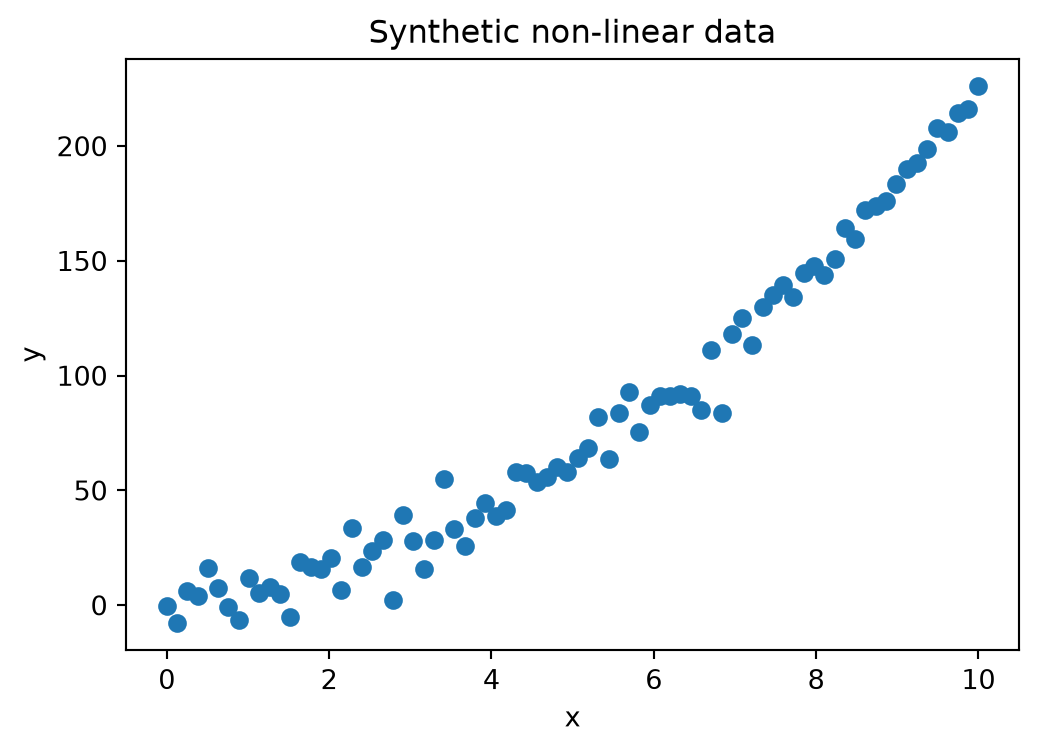

In [85]:
plt.figure(figsize=(6, 4))
plt.scatter(poly_df["x"], poly_df["y"])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic non-linear data")
plt.show()

In [86]:
X = poly_df[["x"]]
y = poly_df["y"]

linear_model = LinearRegression()
linear_model.fit(X, y)

print("Intercept:", linear_model.intercept_)
print("Coefficient:", linear_model.coef_[0])
print("R:", linear_model.score(X, y))

NameError: name 'LinearRegression' is not defined

In [87]:
y_pred_linear = linear_model.predict(X)

plt.figure(figsize=(6, 4))
plt.scatter(poly_df["x"], poly_df["y"], label="Data")
plt.plot(poly_df["x"], y_pred_linear, label="Linear regression")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression on synth curved data")
plt.legend()
plt.show()

NameError: name 'linear_model' is not defined

In [88]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
X_poly

NameError: name 'PolynomialFeatures' is not defined

In [89]:
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

print("Intercept:", poly_model.intercept_)
print("Coefficients:", poly_model.coef_)
print("R:", poly_model.score(X_poly, y))

NameError: name 'LinearRegression' is not defined

In [90]:
y_pred_poly = poly_model.predict(X_poly)

plt.figure(figsize=(6, 4))
plt.scatter(poly_df["x"], poly_df["y"], label="Data")
plt.plot(poly_df["x"], y_pred_poly, label="Polynomial regression")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial regression on curved data")
plt.legend()
plt.show()

NameError: name 'poly_model' is not defined

NameError: name 'y_pred_linear' is not defined

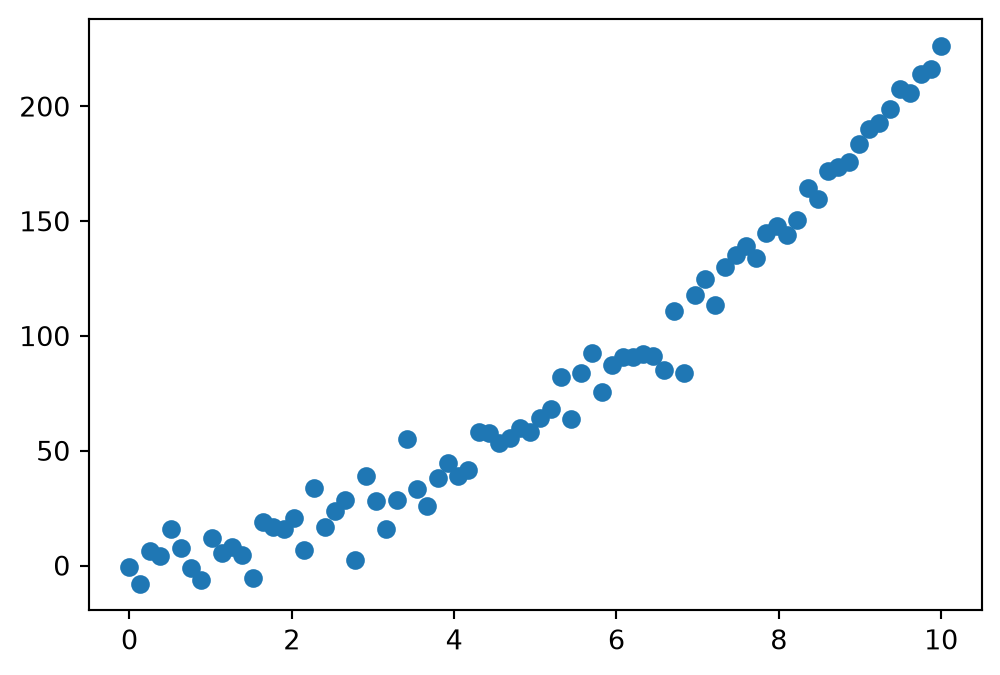

In [91]:
plt.figure(figsize=(6, 4))
plt.scatter(poly_df["x"], poly_df["y"], label="Data")
plt.plot(poly_df["x"], y_pred_linear, label="Linear regression")
plt.plot(poly_df["x"], y_pred_poly, label="Polynomial regression")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()

## Underfitting vs Overfitting

When training a model, there are two common problems:

### Underfitting
- model is too simple
- cannot capture the pattern in the data
- poor performance on both training and test data

### Overfitting
- model is too complex
- fits training data very well
- performs poorly on new (test) data

We will demonstrate this using polynomial regression.

In [92]:
degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20]

results = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_r2 = model.score(X_train_poly, y_train)
    test_r2 = model.score(X_test_poly, y_test)

    results.append((d, train_r2, test_r2))

for d, train_r2, test_r2 in results:
    print(f"Degree {d}: Train R²={train_r2:.3f}, Test R²={test_r2:.3f}")

NameError: name 'PolynomialFeatures' is not defined

### Interpretation

- Degree 1 underfitting (too simple)
- Degree 2 good balance
- Degree 10 verfitting (too complex)

Look at the difference between Train and Test R²:
- small difference means good model
- large difference means overft

![Overfit](https://docs.aws.amazon.com/images/machine-learning/latest/dg/images/mlconcepts_image5.png)

![Bias](https://curiousily.com/static/50d053fd19f5e7ca620bd7e68036a8aa/3e3fe/bias-variance.png)

Competition - we hid part of this dataset from you. Now we will provide it, but without bodymass column, and you will try to build a model yourself with the best possible R squared .
Hints:
- include additional features
- exclude some features
- try different poly transformations and their degrees
- try preprocess your data
- Get back to NA treatment
- all of the above